# Combined mmFall + TI IWR6843 Datasets — Cross-Dataset Explorer & Visualizer

This notebook inspects and compares the two primary mmWave radar fall detection datasets in this repository:
1. **`mmFall`**: 77 GHz TI IWR1443 sensor (1,182 motion windows, DS0/DS1/DS2).
2. **`TI IWR6843`**: 60–64 GHz sensor (728 motion windows across 3 human subjects).

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists(): preproc_dir = Path("../../datasets/preprocessed")

X_mmfall = np.load(preproc_dir / "X_mmfall_clean_balanced.npy")
y_mmfall = np.load(preproc_dir / "y_mmfall_clean_balanced.npy")

X_ti = np.load(preproc_dir / "X_ti_clean_balanced.npy")
y_ti = np.load(preproc_dir / "y_ti_clean_balanced.npy")

print(f"mmFall Dataset (77 GHz): {X_mmfall.shape} | Labels: {np.bincount(y_mmfall.astype(int))}")
print(f"TI IWR6843 Dataset (60 GHz): {X_ti.shape} | Labels: {np.bincount(y_ti.astype(int))}")
print(f"Total Combined Dataset Size: {len(X_mmfall) + len(X_ti)} balanced motion clips (~1:1 ratio)")

mmFall Dataset (77 GHz): (1182, 10, 64, 4) | Labels: [591 591]
TI IWR6843 Dataset (60 GHz): (728, 10, 64, 4) | Labels: [364 364]
Total Combined Dataset Size: 1910 balanced motion clips (~1:1 ratio)


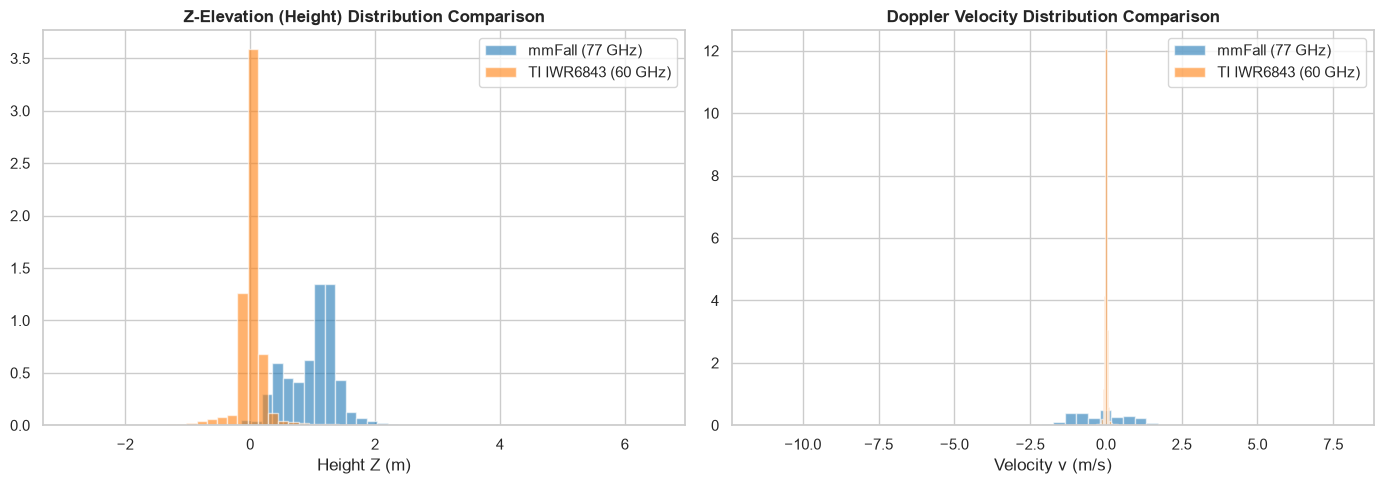

In [2]:
# Compare Spatial Feature Distributions (mmFall vs TI IWR6843)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(X_mmfall[..., 2].flatten(), bins=50, alpha=0.6, color="tab:blue", label="mmFall (77 GHz)", density=True)
axes[0].hist(X_ti[..., 2].flatten(), bins=50, alpha=0.6, color="tab:orange", label="TI IWR6843 (60 GHz)", density=True)
axes[0].set_title("Z-Elevation (Height) Distribution Comparison", fontweight="bold")
axes[0].set_xlabel("Height Z (m)")
axes[0].legend()

axes[1].hist(X_mmfall[..., 3].flatten(), bins=50, alpha=0.6, color="tab:blue", label="mmFall (77 GHz)", density=True)
axes[1].hist(X_ti[..., 3].flatten(), bins=50, alpha=0.6, color="tab:orange", label="TI IWR6843 (60 GHz)", density=True)
axes[1].set_title("Doppler Velocity Distribution Comparison", fontweight="bold")
axes[1].set_xlabel("Velocity v (m/s)")
axes[1].legend()
plt.tight_layout()
plt.show()